# Tutorial 2-jet: LHC jet tagging

This notebook applies the full SNAC-Pack pipeline (hardware-aware global search,
combined QAT and pruning, and hls4ml synthesis) to the **LHC jet tagging** dataset
used in the preceding hls4ml tutorial.

**Continuing from the hls4ml tutorial.** Part 1 introduced the jet tagging task and
built a baseline MLP. Part 3 compressed it with pruning. Here, SNAC-Pack replaces
the manual model-design step with an automated hardware-aware search, adding an
explicit FPGA resource and latency objective to the same dataset.

| Step | Description |
|---|---|
| 1 | Load and visualize the jet dataset |
| 2 | Run a hardware-aware global search using NSGA-II and the `rule4ml` surrogate |
| 3 | Examine the Pareto front: accuracy versus chip cost |
| 4 | Compress the best architecture with combined QAT and iterative magnitude pruning |
| 5 | Export the compressed model to an HLS C++ project with hls4ml |

All search parameters are controlled by `t2_jet_config.yaml` in this directory.

In [ ]:
import sys, platform
print(sys.executable)
print(platform.python_version())
import optuna, sqlite3

/opt/miniconda3/envs/snac-pack-refactor/bin/python
3.10.16
optuna OK


In [2]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

import yaml
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from utils.tf_global_search import GlobalSearchTF
from utils.tf_local_search_combined import combined_local_search_entrypoint
from data.hls4ml_jets_dataset import load_and_preprocess_hls4ml_jets
from utils.tf_visualization import (
    plot_pareto_fronts,
    plot_interactive_2d_pareto,
    plot_3d_pareto_front_heatmap,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')
print('TensorFlow:', tf.__version__)

cfg     = yaml.safe_load(open(Path.cwd() / 't2_jet_config.yaml'))
ds_cfg  = cfg['dataset']
s_cfg   = cfg['search']
ss_cfg  = cfg['search_space']
ls_cfg  = cfg['local_search']
out_cfg = cfg['output']

RESULTS_DIR = out_cfg['results_dir']
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results dir : {RESULTS_DIR}')
print(f'n_trials={s_cfg["n_trials"]}, epochs={s_cfg["epochs"]}, hw_metrics={s_cfg["use_hardware_metrics"]}')

2026-05-22 22:01:55.496570: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.15.1
Results dir : ./results/tutorial2_jet
n_trials=20, epochs=5, hw_metrics=True


## Dataset: LHC jet tagging

At the Large Hadron Collider, proton–proton collisions produce **jets**, collimated
sprays of particles, whose origin depends on the hard-scatter process.  Tagging
which particle type produced a jet is essential for many physics analyses.

Each sample is described by **16 high-level jet-substructure observables** derived
from the raw detector hits.  These observables encode shape and multiplicity
properties of the jet without retaining the full 4-vector of every constituent.

The five jet classes are:

| Label | Jet type |
|---|---|
| `g` | Gluon jet |
| `q` | Light-quark jet |
| `t` | Top-quark jet |
| `w` | W-boson jet |
| `z` | Z-boson jet |

The dataset is `hls4ml_lhc_jets_hlf` from OpenML (830 000 events, 16 features).
It is the same dataset used in the hls4ml tutorial you ran before this one.
Labels are encoded alphabetically by `sklearn.preprocessing.LabelEncoder`
(`g→0, q→1, t→2, w→3, z→4`).

<details>
<summary>Background: the 16 features</summary>

The features are infrared-safe jet-substructure observables measured after applying
a modified mass-drop tagger (mMDT / soft-drop with β=0):
`zlogz, c1_b0_mmdt, c1_b1_mmdt, c1_b2_mmdt, c2_b1_mmdt, c2_b2_mmdt,
d2_b1_mmdt, d2_b2_mmdt, d2_a1_b1_mmdt, d2_a1_b2_mmdt, m2_b1_mmdt,
m2_b2_mmdt, n2_b1_mmdt, n2_b2_mmdt, mass_mmdt, multiplicity`.

Because these are scalar observables rather than raw particle lists, the network
takes a flat 16-dimensional vector as input, a standard tabular classification
problem.

</details>

Fetching hls4ml_lhc_jets_hlf from OpenML (cached after first download)...
hls4ml jet tagging data loaded and preprocessed:
  x_train shape : (2000, 16),  x_test shape : (166000, 16)
  y_train shape : (2000,),  y_test shape : (166000,)
  classes       : ['g', 'q', 't', 'w', 'z']


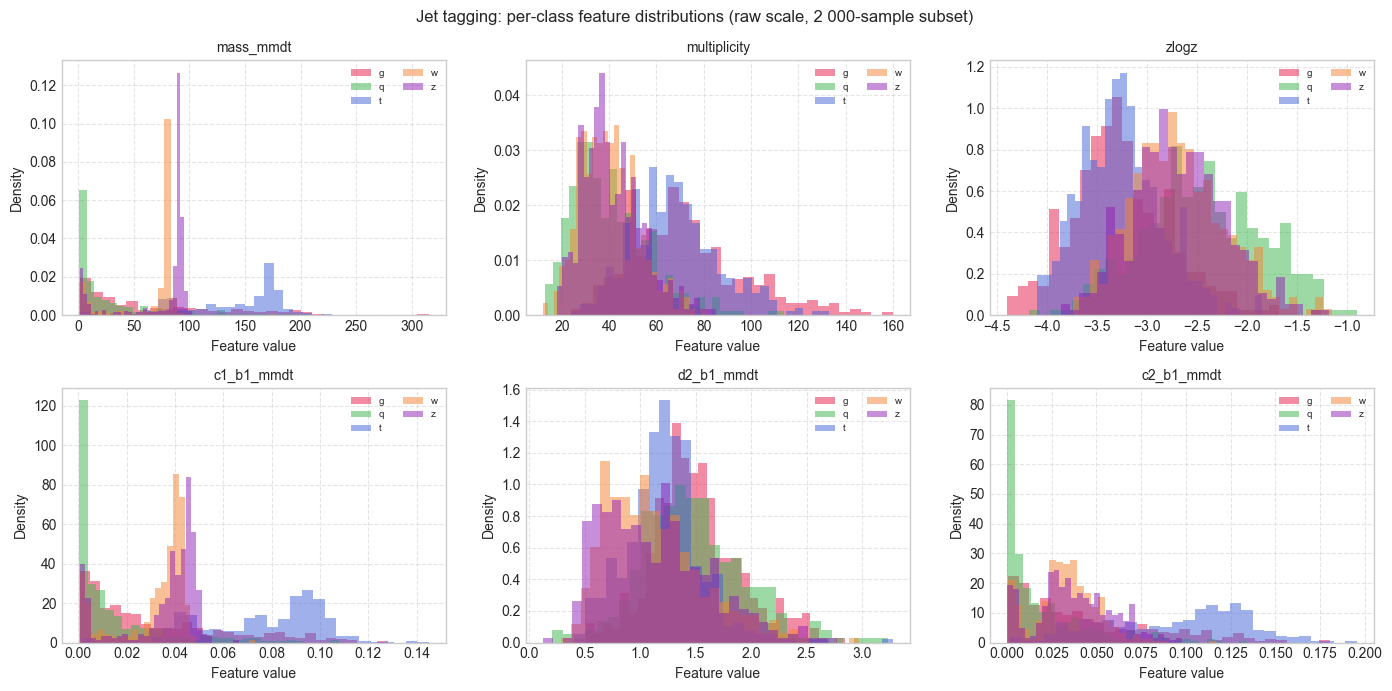

Input dimension : 16  (16 high-level jet-substructure features)
Classes         : ['g', 'q', 't', 'w', 'z']  (5 jet types)


In [3]:
# Load a small unnormalized subset for visualization only
x_viz, y_viz, _, _ = load_and_preprocess_hls4ml_jets(
    subset_size=min(ds_cfg.get('subset_size', 5000), 2000),
    normalize=False,
    flatten=True,
    one_hot=False,
    num_classes=ds_cfg['num_classes'],
)

JET_CLASSES = ['g', 'q', 't', 'w', 'z']
JET_FEATURE_NAMES = [
    'zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt',
    'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt',
    'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt',
    'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity',
]
SHOW   = ['mass_mmdt', 'multiplicity', 'zlogz', 'c1_b1_mmdt', 'd2_b1_mmdt', 'c2_b1_mmdt']
FIDX   = [JET_FEATURE_NAMES.index(f) for f in SHOW]
COLORS = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, fidx, fname in zip(axes.flat, FIDX, SHOW):
    for ci, (cn, col) in enumerate(zip(JET_CLASSES, COLORS)):
        mask = y_viz == ci
        if mask.any():
            ax.hist(x_viz[mask, fidx], bins=30, alpha=0.5,
                    color=col, label=cn, density=True)
    ax.set_title(fname, fontsize=10)
    ax.set_xlabel('Feature value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, linestyle='--', alpha=0.5)
plt.suptitle(
    'Jet tagging: per-class feature distributions (raw scale, 2 000-sample subset)',
    fontsize=12,
)
plt.tight_layout()
plt.show()
print(f'Input dimension : {x_viz.shape[1]}  (16 high-level jet-substructure features)')
print(f'Classes         : {JET_CLASSES}  ({len(JET_CLASSES)} jet types)')

## Configuration comparison

The table below shows the differences between the Tutorial 1 and Tutorial 2-jet
configurations.  The YAML structure is identical; only the task-specific entries
change.

| Block | Tutorial 1 (MNIST MLP) | Tutorial 2-jet (jet tagging) |
|---|---|---|
| `dataset.name` | `mnist` | `hls4ml_jets` |
| `dataset.num_classes` | 10 | 5 |
| `search.objective_names` | accuracy, BOPs, avg_resource, clock_cycles | same |
| `search.n_trials / epochs` | 8 / 3 | 2 / 10 |
| `search_space.output_dim` | 10 | 5 |
| `search_space.block_types` | `[MLP]` | `[MLP, None]` |
| `synthesis:` section | not present | present |

The `synthesis:` block specifies which local-search precision to load when building
the hls4ml project, and where to write the output.

In [4]:
with open(Path.cwd() / 't2_jet_config.yaml') as fh:
    print(fh.read())

# Tutorial 2-jet: hls4ml jet tagging search — from search to silicon
#
# The jet tagging dataset (hls4ml_lhc_jets_hlf) is downloaded automatically
# on the first run via sklearn.datasets.fetch_openml and cached under
# ~/.scikit_learn_data.  Subsequent runs load from the cache.
#
# rule4ml hardware metrics require the conda library path:
#   export LD_LIBRARY_PATH="$CONDA_PREFIX/lib:${LD_LIBRARY_PATH:-}"

dataset:
  name: hls4ml_jets
  subset_size: 5000        # subsample training split (full split is ~664k)
  val_subset_size: 8000    # stratified subsample of the ~166k test split used for per-epoch validation
  normalize: true
  flatten: true
  one_hot: true
  num_classes: 5

search:
  model_type: block
  n_trials: 20
  epochs: 5
  n_folds: 1
  use_hardware_metrics: true
  objective_names: [performance_metric, bops, avg_resource, clock_cycles]
  maximize_flags: [true, false, false, false]

search_space:
  mlp_width_space: [16, 32, 64, 128]
  act_space: [ReLU, LeakyReLU]
  norm_space: 

## Stage 1: Global search with four objectives

The search simultaneously optimizes:

1. **Accuracy** (maximise)
2. **BOPs**: bit operations, a proxy for weight memory (minimize)
3. **avg_resource**: arithmetic mean of LUT%, DSP%, BRAM%, FF% estimates (minimize)
4. **clock_cycles**: predicted inference latency (minimize)

The Pareto front contains all architectures that are not dominated on all four axes.
Model selection is performed by choosing the architecture that meets the application's
latency and resource budget.

In [5]:
obj_names = s_cfg['objective_names']
max_flags = s_cfg['maximize_flags']
n_folds   = s_cfg.get('n_folds', 1)

searcher = GlobalSearchTF(
    search_space_path=ss_cfg,
    results_dir=RESULTS_DIR,
)

study = searcher.run_search(
    model_type=s_cfg['model_type'],
    n_trials=s_cfg['n_trials'],
    epochs=s_cfg['epochs'],
    dataset=ds_cfg['name'],
    subset_size=ds_cfg.get('subset_size'),
    objectives=obj_names,
    maximize_flags=max_flags,
    use_hardware_metrics=s_cfg['use_hardware_metrics'],
    one_hot=ds_cfg['one_hot'],
    n_folds=n_folds,
    num_classes=ds_cfg['num_classes'],
    normalize=ds_cfg['normalize'],
    flatten=ds_cfg['flatten'],
    val_subset_size=ds_cfg.get('val_subset_size'),  # forwarded to the loader; keeps per-epoch validation cheap
    storage=None,
)
print('Global search complete.')


Starting BLOCK Global Search on HLS4ML_JETS

Fetching hls4ml_lhc_jets_hlf from OpenML (cached after first download)...


[I 2026-05-22 22:02:14,669] A new study created in memory with name: no-name-7cd7db96-737e-494d-9785-f61514ce6e85


hls4ml jet tagging data loaded and preprocessed:
  x_train shape : (5000, 16),  x_test shape : (8000, 16)
  y_train shape : (5000, 5),  y_test shape : (8000, 5)
  classes       : ['g', 'q', 't', 'w', 'z']
Using in-memory Optuna study (single-node mode)


[I 2026-05-22 22:02:27,541] Trial 0 finished with values: [0.6351249814033508, 13189120.0, 3.7874999999999996, 44.94] and parameters: {'b0': 'MLP', 'b1': 'MLP', 'b2': 'None', 'b3': 'None', 'b0_MLP_units': 1, 'b0_MLP_act': 'LeakyReLU', 'b0_MLP_norm': 'batch', 'b1_MLP_units': 2, 'b1_MLP_act': 'LeakyReLU', 'b1_MLP_norm': None, 'MLP_Head_width_0': 3, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'LeakyReLU', 'MLP_Head_acts_1': 'LeakyReLU', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 0: Accuracy=0.6351, BOPs=13189120, AvgResource=3.79%, Cycles=44.94


...

Trial 17: Accuracy=0.6595, BOPs=4849664, AvgResource=1.52%, Cycles=127.09


[I 2026-05-22 22:05:31,391] Trial 18 finished with values: [0.6933749914169312, 14286848.0, 4.05, 37.92] and parameters: {'b0': 'MLP', 'b1': 'None', 'b2': 'None', 'b3': 'MLP', 'b0_MLP_units': 2, 'b0_MLP_act': 'LeakyReLU', 'b0_MLP_norm': 'batch', 'b3_MLP_units': 1, 'b3_MLP_act': 'ReLU', 'b3_MLP_norm': None, 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 3, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'LeakyReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}.


Trial 18: Accuracy=0.6934, BOPs=14286848, AvgResource=4.05%, Cycles=37.92


[I 2026-05-22 22:05:37,698] Trial 19 finished with values: [0.6423749923706055, 2179072.0, 0.775, 138.01] and parameters: {'b0': 'MLP', 'b1': 'None', 'b2': 'MLP', 'b3': 'None', 'b0_MLP_units': 1, 'b0_MLP_act': 'ReLU', 'b0_MLP_norm': 'batch', 'b2_MLP_units': 0, 'b2_MLP_act': 'LeakyReLU', 'b2_MLP_norm': 'batch', 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'LeakyReLU', 'MLP_Head_acts_1': 'LeakyReLU', 'MLP_Head_acts_2': 'LeakyReLU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'batch'}.


Trial 19: Accuracy=0.6424, BOPs=2179072, AvgResource=0.78%, Cycles=138.01

CSV results saved to ./results/tutorial2_jet/block_search_results.csv (20 trials)

🏆 Best model architecture (Trial 10) saved for local search:
   - Source: ./results/tutorial2_jet/trial_yamls/trial_10_arch.yaml
   - Destination: ./results/tutorial2_jet/best_model_for_local_search.yaml
   - Accuracy: 0.7154
2D Pareto fronts plot saved to ./results/tutorial2_jet/pareto_fronts_2d.png
3D Pareto front plot saved to ./results/tutorial2_jet/pareto_front_3d.html

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 0):
  Values: {'performance_metric': 0.6351249814033508, 'bops': 13189120.0, 'avg_resource': 3.7874999999999996, 'clock_cycles': 44.94}
  Params: {'b0': 'MLP', 'b1': 'MLP', 'b2': 'None', 'b3': 'None', 'b0_MLP_units': 1, 'b0_MLP_act': 'LeakyReLU', 'b0_MLP_norm': 'batch', 'b1_MLP_units': 2, 'b1_MLP_act': 'LeakyReLU', 'b1_MLP_norm': None, 'MLP_Head_width_0': 3, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'LeakyReLU', 'MLP_

## Pareto front

The interactive scatter plot displays all trials.
Hover over any point to inspect the architecture parameters and objective values.
The latency-budget slider in the next cell highlights which architectures satisfy
a given clock-cycle constraint.

Highest-accuracy trial : 10  Accuracy : 0.7154  BOPs : 2.37e+07


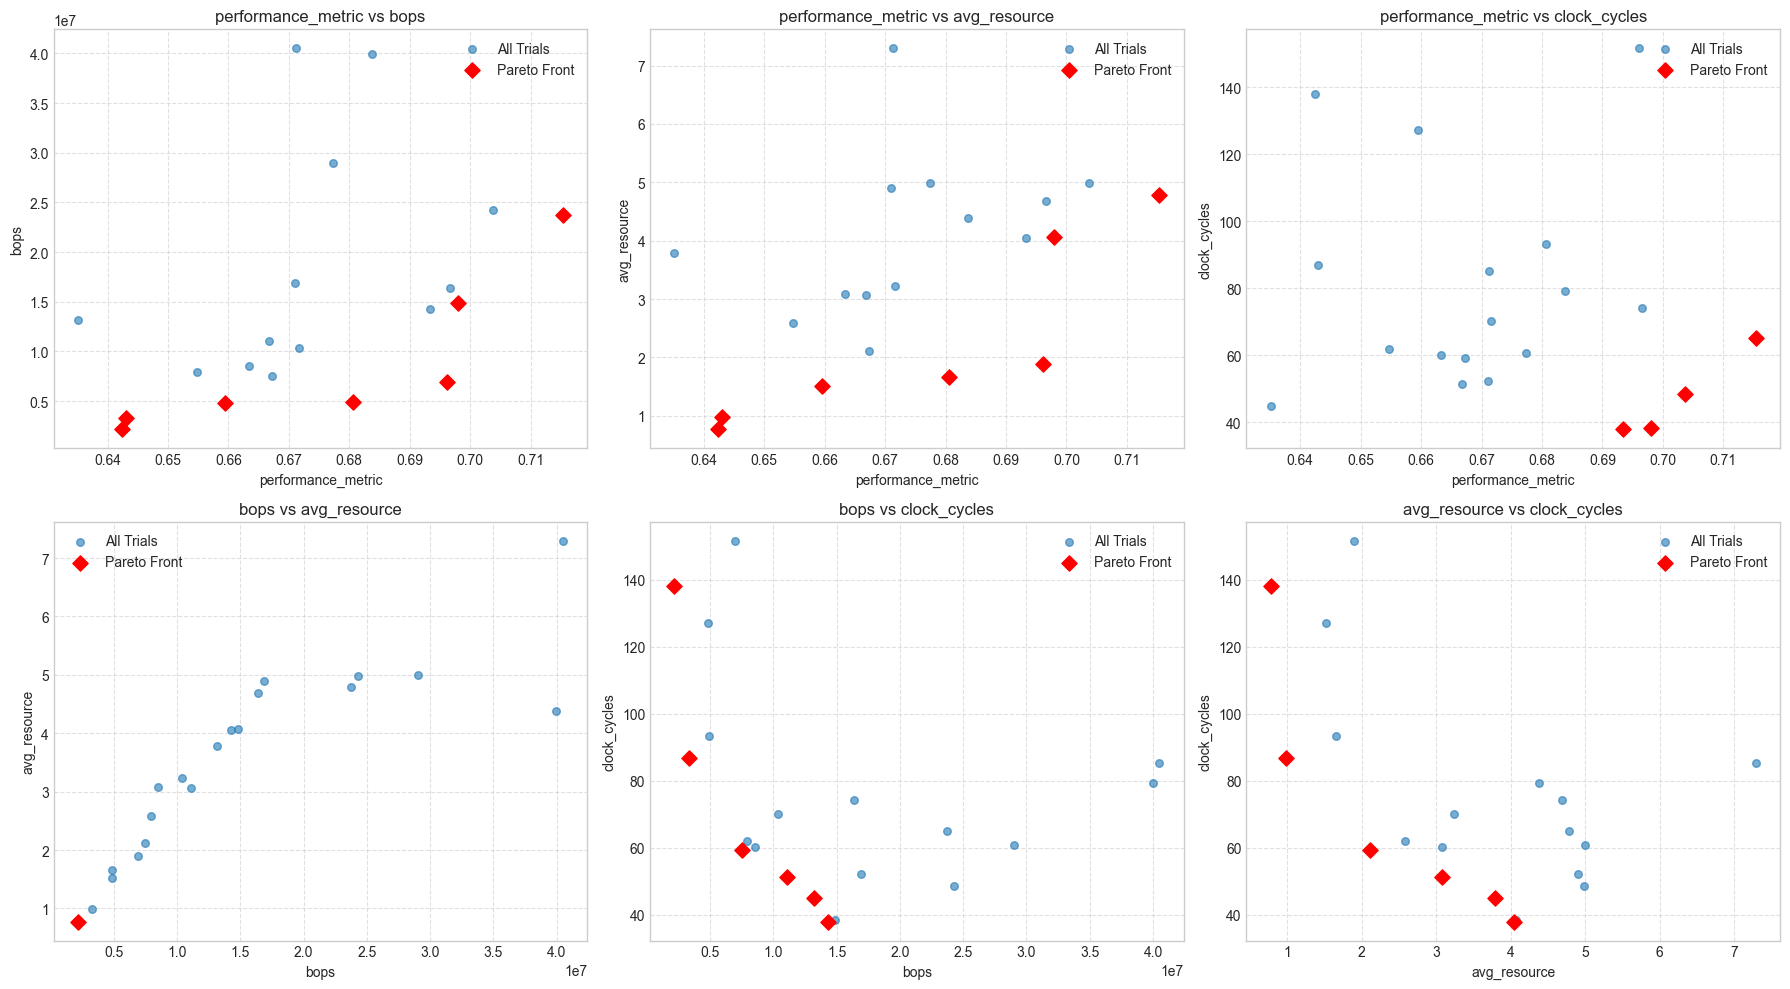

2D Pareto fronts plot saved to ./results/tutorial2_jet/pareto_fronts_2d.png


Interactive 2D Pareto front plot saved to ./results/tutorial2_jet/interactive_pareto_front_2d.html


3D Pareto front plot saved to ./results/tutorial2_jet/pareto_front_3d.html


In [6]:
results_df = pd.DataFrame(searcher.results)

if not results_df.empty:
    best = results_df.loc[results_df['performance_metric'].idxmax()]
    print(f'Highest-accuracy trial : {int(best["trial"])}  '
          f'Accuracy : {best["performance_metric"]:.4f}  '
          f'BOPs : {best["bops"]:.2e}')

    obj_info = list(zip(obj_names, max_flags))
    plot_pareto_fronts(results_df, obj_info, save_dir=RESULTS_DIR, show=True)
    plot_interactive_2d_pareto(results_df, obj_info, save_dir=RESULTS_DIR, show=True)
    if len(obj_names) >= 4:
        plot_3d_pareto_front_heatmap(results_df, obj_info, save_dir=RESULTS_DIR, show=True)
else:
    print('No results available. Run the global search cell above first.')

## Latency budget selection

Adjust the slider to set a clock-cycle budget.
Architectures within the budget are shown in teal; those exceeding it are shown in
grey. This shows the best-feasible / closest-feasible selection that the
pipeline applies automatically during constrained search.

In [ ]:
def _plot_latency_budget(results_df, budget_cc):
    if 'clock_cycles' not in results_df.columns:
        print('clock_cycles column not present. '
              'Confirm that use_hardware_metrics is true in the config.')
        return
    feasible   = results_df[results_df['clock_cycles'] <= budget_cc]
    infeasible = results_df[results_df['clock_cycles'] > budget_cc]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(infeasible['clock_cycles'], infeasible['performance_metric'],
               alpha=0.4, color='gray', label='Exceeds budget', s=40)
    ax.scatter(feasible['clock_cycles'], feasible['performance_metric'],
               alpha=0.9, color='teal', label='Within budget', s=60, zorder=5)
    ax.axvline(x=budget_cc, color='red', linestyle='--',
               linewidth=2, label=f'Budget: {budget_cc} cc')
    ax.set(xlabel='Clock cycles (predicted latency)',
           ylabel='Accuracy',
           title='Accuracy vs. latency')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    print(f'{len(feasible)} of {len(results_df)} architectures satisfy the '
          f'{budget_cc}-cycle budget.')

if not results_df.empty and 'clock_cycles' in results_df.columns:
    cc_min     = int(results_df['clock_cycles'].min())
    cc_max     = int(results_df['clock_cycles'].max())
    cc_step    = max(1, (cc_max - cc_min) // 20)
    cc_default = int(cc_min + (cc_max - cc_min) * 0.5)

    try:
        import ipywidgets as widgets
        widgets.interact(
            lambda budget_cc: _plot_latency_budget(results_df, budget_cc),
            budget_cc=widgets.IntSlider(
                min=cc_min, max=cc_max, step=cc_step, value=cc_default,
                description='Budget (cc):',
                style={'description_width': 'initial'},
                layout=widgets.Layout(width='500px'),
            ),
        )
    except ImportError:
        _plot_latency_budget(results_df, cc_default)
else:
    print('Run the global search cell first.')

interactive(children=(IntSlider(value=94, description='Budget (cc):', layout=Layout(width='500px'), max=151, m…

## Stage 2: Combined QAT and pruning

Block-based models use k-fold cross-validation during global search.
For these models, SNAC-Pack applies the combined local search strategy, in which
quantization-aware training and magnitude pruning are interleaved within each
training iteration rather than run as separate sequential phases.
The implementation is in `utils/tf_local_search_combined.py`.

In [8]:
LOCAL_RESULTS_DIR = os.path.join(RESULTS_DIR, 'local_search_combined')
LOCAL_CONFIG_PATH = os.path.join(RESULTS_DIR, 'local_search_config.yaml')
ARCH_YAML_PATH    = os.path.join(RESULTS_DIR, 'best_model_for_local_search.yaml')

local_search_settings = {
    'pruning_settings': {
        'iterations':           ls_cfg['pruning_iterations'],
        'epochs_per_iteration': ls_cfg['pruning_epochs'],
        'pruning_rate':         ls_cfg['pruning_rate'],
    },
    'qat_settings': {
        'epochs':          ls_cfg['qat_epochs'],
        'precision_pairs': ls_cfg['precision_pairs'],
    },
}
with open(LOCAL_CONFIG_PATH, 'w') as fh:
    yaml.dump(local_search_settings, fh)

# val_subset_size keeps the per-epoch validation cheap: the loader stratified-
# subsamples the ~166k test split (see data/hls4ml_jets_dataset.py).
x_train, y_train, x_test, y_test = load_and_preprocess_hls4ml_jets(
    subset_size=ds_cfg.get('subset_size'),
    val_subset_size=ds_cfg.get('val_subset_size'),
    normalize=ds_cfg['normalize'],
    flatten=ds_cfg['flatten'],
    one_hot=True,
    num_classes=ds_cfg['num_classes'],
)

if not os.path.exists(ARCH_YAML_PATH):
    print(f'Architecture YAML not found: {ARCH_YAML_PATH}')
    print('Complete the global search first.')
    combined_df = pd.DataFrame()
else:
    combined_df = combined_local_search_entrypoint(
        architecture_yaml_path=ARCH_YAML_PATH,
        local_search_config_path=LOCAL_CONFIG_PATH,
        dataset=(x_train, y_train, x_test, y_test),
        results_dir=LOCAL_RESULTS_DIR,
    )

Fetching hls4ml_lhc_jets_hlf from OpenML (cached after first download)...
hls4ml jet tagging data loaded and preprocessed:
  x_train shape : (5000, 16),  x_test shape : (8000, 16)
  y_train shape : (5000, 5),  y_test shape : (8000, 5)
  classes       : ['g', 'q', 't', 'w', 'z']

 STARTING COMBINED QAT+PRUNING LOCAL SEARCH 
Baseline FP32 BOPs: 2.53e+07

==================== Precision: <16,6> ====================
  QAT warmup (10 epochs)... accuracy=0.7301 (val), eff_bops=6.32e+06
  Iter 1/8: acc=0.7380 (val)  sparsity=0.3934  eff_bops=3.83e+06 *
  Iter 2/8: acc=0.7339 (val)  sparsity=0.6295  eff_bops=2.34e+06
  Iter 3/8: acc=0.7406 (val)  sparsity=0.7711  eff_bops=1.45e+06 *
  Iter 4/8: acc=0.7384 (val)  sparsity=0.8560  eff_bops=9.10e+05
  Iter 5/8: acc=0.7339 (val)  sparsity=0.9070  eff_bops=5.88e+05
  Iter 6/8: acc=0.7201 (val)  sparsity=0.9376  eff_bops=3.94e+05
  Iter 7/8: acc=0.6741 (val)  sparsity=0.9560  eff_bops=2.78e+05
  Iter 8/8: acc=0.4996 (val)  sparsity=0.9669  eff_bops=2

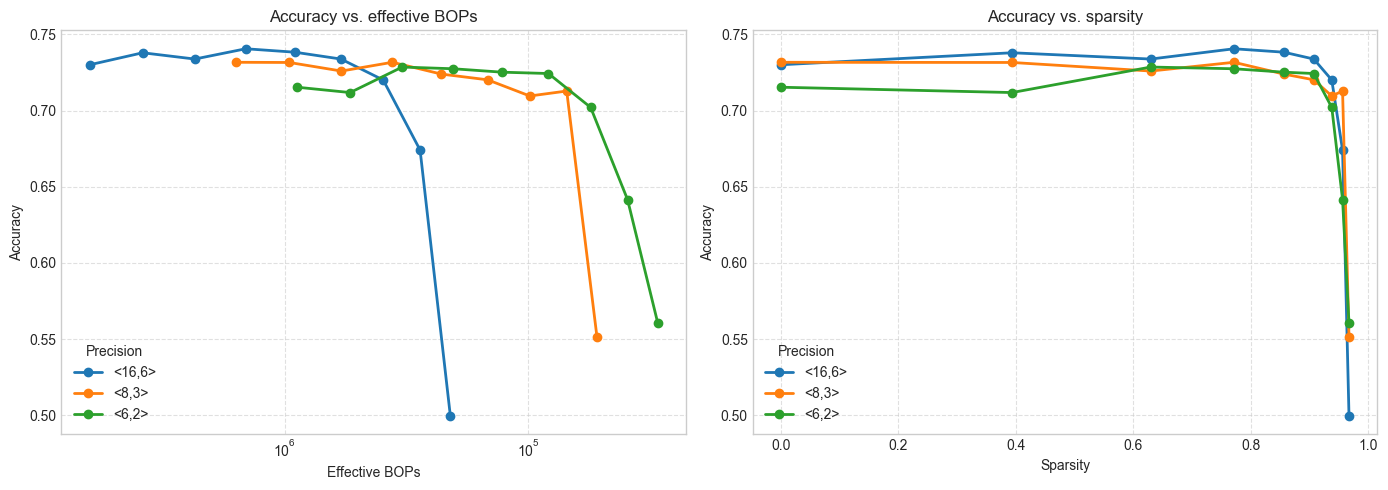

In [9]:
if isinstance(combined_df, pd.DataFrame) and not combined_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for prec in combined_df['Precision'].unique():
        sub = combined_df[combined_df['Precision'] == prec]
        axes[0].plot(sub['EffectiveBOPs'], sub['Accuracy'],
                     marker='o', linewidth=2, label=prec)
        axes[1].plot(sub['Sparsity'], sub['Accuracy'],
                     marker='o', linewidth=2, label=prec)
    axes[0].set(xlabel='Effective BOPs', ylabel='Accuracy',
                title='Accuracy vs. effective BOPs')
    axes[0].set_xscale('log')
    axes[0].invert_xaxis()
    axes[0].legend(title='Precision')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[1].set(xlabel='Sparsity', ylabel='Accuracy',
                title='Accuracy vs. sparsity')
    axes[1].legend(title='Precision')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print('No local search results available.')

## Stage 3: hls4ml synthesis

This stage loads the best QAT model at the precision specified in
`t2_jet_config.yaml` and generates an HLS C++ project using hls4ml.
The project can be compiled for C-simulation and then synthesised with Vivado to
produce a bitstream and a post-synthesis resource and latency report.

**Note:** the `hls_model.build()` call requires Vivado in the system PATH.
If Vivado is not available, the cells below will still generate the HLS project;
the build step will print an informative message and exit cleanly.

In [ ]:
try:
    from utils.tf_synthesis import run_synthesis_from_config

    syn_cfg = cfg.get('synthesis', {})
    if not syn_cfg:
        print('No synthesis section found in t2_jet_config.yaml.')
    else:
        model, input_shape, hls_model = run_synthesis_from_config(
            config=cfg,
            base_dir=Path.cwd(),
        )
        print(f'Loaded model: {syn_cfg["total_bits"]}b{syn_cfg["int_bits"]}i, '
              f'input shape {input_shape}')
        print(f'HLS project written to: {syn_cfg["hls_output_dir"]}')
except Exception as exc:
    print(f'Synthesis setup error: {exc}')
    hls_model = None

/opt/miniconda3/envs/snac-pack-refactor/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning:

The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.



Interpreting Model
Topology:
Layer name: input_8, layer type: InputLayer, input shapes: [[None, 16]], output shape: [None, 16]
Layer name: mlp_block_1_dense_0, layer type: QDense, input shapes: [[None, 16]], output shape: [None, 64]
Layer name: re_lu_13, layer type: Activation, input shapes: [[None, 64]], output shape: [None, 64]
Layer name: mlp_block_2_dense_0, layer type: QDense, input shapes: [[None, 64]], output shape: [None, 32]
Layer name: re_lu_14, layer type: Activation, input shapes: [[None, 32]], output shape: [None, 32]
Layer name: flatten_1, layer type: Reshape, input shapes: [[None, 32]], output shape: [None, 32]
Layer name: classifier_head_dense_0, layer type: QDense, input shapes: [[None, 32]], output shape: [None, 64]
Layer name: classifier_head_bn_0, layer type: BatchNormalization, input shapes: [[None, 64]], output shape: [None, 64]
Layer name: leaky_re_lu_10, layer type: LeakyReLU, input shapes: [[None, 64]], output shape: [None, 64]
Layer name: classifier_head_dense

In [ ]:
# C-simulation compile
if hls_model is not None:
    try:
        hls_model.compile()
        print('HLS model compiled successfully.')
    except Exception as exc:
        print(f'HLS compile error: {exc}')
else:
    print('No hls_model object. Run the synthesis cell above first.')

Writing HLS project
Done
In file included from firmware/myproject.cpp:3:
In file included from firmware/myproject.h:4:
In file included from firmware/ap_types/ap_fixed.h:21:
In file included from firmware/ap_types/ap_fixed_base.h:25:
In file included from firmware/ap_types/ap_int.h:319:
firmware/ap_types/ap_int_special.h:60:7: error: reference to 'complex' is ambiguous
   60 | class complex<ap_int<_AP_W> > {
      |       ^
/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/include/c++/v1/__fwd/complex.h:22:28: note: candidate found by name lookup is 'std::__1::complex'
   22 | class _LIBCPP_TEMPLATE_VIS complex;
      |                            ^
firmware/ap_types/ap_int_special.h:32:30: note: candidate found by name lookup is 'std::complex'
   32 | template<typename _Tp> class complex;
      |                              ^
firmware/ap_types/ap_int_special.h:193:30: error: reference to 'complex' is ambiguous
  193 | inline bool operator==(const complex<ap_int<_AP_W> > &__x, co

In [ ]:
# Vivado RTL synthesis (requires Vivado in PATH)
if hls_model is not None:
    try:
        hls_model.build()
        print('Vivado synthesis complete. '
              'Resource and latency report available in the HLS project directory.')
    except Exception as exc:
        print(f'Vivado synthesis unavailable: {exc}')
        print('The HLS project is still valid and can be synthesised on a '
              'machine with Vivado installed.')
else:
    print('No hls_model object. Run the synthesis cell above first.')

Project myproject_prj does not exist. Rerun "hls4ml build -p /Users/dimstademler/Desktop/eth-local/snac_pack/nac-opt-mcp/tutorials_v2/tutorial_2/results/tutorial2_jet/hls_project".
Vivado synthesis complete. Resource and latency report available in the HLS project directory.


sh: vivado_hls: command not found


## Summary

| Stage | Description |
|---|---|
| Dataset | LHC jet tagging (hls4ml_lhc_jets_hlf), 16 high-level features, 5-class multiclass |
| Global search | NSGA-II with `rule4ml` surrogate over accuracy, BOPs, resources, and latency |
| Budget selection | Interactive Pareto visualization with adjustable latency constraint |
| Local search | Combined QAT and iterative magnitude pruning |
| Synthesis | hls4ml HLS project generation and optional Vivado RTL synthesis |
| Planner | Search planner converts a structured specification to a complete YAML config |

The complete pipeline, from dataset to synthesisable FPGA model, is driven
by a single YAML configuration file and can also be invoked from an AI agent
through the MCP tool interface.